# SENTIMENT ANALYSIS AI

In [1]:
import json
import csv
import os
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
INPUT_FILES = [
    "data_training/tweets_1.json",
    "data_training/tweets_2.json",
]
OUTPUT_PATH = "data_training/text.csv"

os.makedirs("data_training", exist_ok=True)

with open(OUTPUT_PATH, "w", newline="", encoding="utf-8") as out:
    writer = csv.writer(out)
    writer.writerow(["text"])
    for path in INPUT_FILES:
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    tweet = json.loads(line)
                    text = tweet.get("content", "")
                    if text:
                        writer.writerow([text])
                except json.JSONDecodeError:
                    continue

print(f"Saved to {OUTPUT_PATH}")


Saved to data_training/text.csv


In [2]:
df = pd.read_csv("data_training/data.csv")

In [16]:
df.head(10)

,text
0,Pagaya Technologies&amp;nbsp; Non-GAAP EPS of ...
1,"Nasdaq, S&amp;P, Dow futures drift down after ..."
2,Kaixin Auto stock jumps on intention order for...
3,"Sea Non-GAAP EPS of -$1.03 beats by $0.03, rev..."
4,"Asia Cup 2022: Still in practice, will blow my..."
5,#Cannabis #News #Newsletter ND cannabis initia...
6,#Cannabis #News #AllU.S. Several state marijua...
7,🤩This is a good practice with a lot of potenti...
8,"Partnering with #Roblox, #MTV has introduced i..."
9,Today Update : Amritsar News – Bomb planted in...


In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [4]:
print(f"Training set size: {len(df_train)}, Test set size: {len(df_test)}")

Training set size: 80000, Test set size: 20000


---

## twitter-roberta-base-sentiment model

In [6]:
from transformers import pipeline

pipe = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-sentiment")

/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 61689.97it/s]


In [20]:
from tqdm.auto import tqdm

BATCH_SIZE = 256

texts = df["text"].fillna("").tolist()
labels = []

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch = texts[i:i + BATCH_SIZE]
    results = pipe(batch, truncation=True, max_length=128, batch_size=BATCH_SIZE)
    labels.extend(r["label"] for r in results)

LABEL_MAP = {"LABEL_0": "negative", "LABEL_1": "neutral", "LABEL_2": "positive"}
df["sentiment_label"] = [LABEL_MAP[l] for l in labels]
df.to_csv("data_training/data.csv", index=False)
print("Done:", df["sentiment_label"].value_counts())

100%|██████████| 391/391 [15:33<00:00,  2.39s/it]


Done: sentiment_label
neutral     69691
negative    17264
positive    13045
Name: count, dtype: int64


---

### Training huawei-noah/TinyBERT_General_4L_312D

In [5]:
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
MODEL_NAME = "huawei-noah/TinyBERT_General_4L_312D"
SAVE_PATH = "models/sentiment"

In [6]:
class TweetDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.encodings = tokenizer(
            df["text"].fillna("").tolist(),
            truncation=True, padding=True, max_length=128
        )
        self.labels = df["sentiment_label"].map(LABEL2ID).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()} | {"labels": torch.tensor(self.labels[idx])}

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)

train_dataset = TweetDataset(df_train, tokenizer)
test_dataset  = TweetDataset(df_test,  tokenizer)

Loading weights: 100%|██████████| 71/71 [00:00<00:00, 24027.40it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     | 
-------------------------------------------+------------+-
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

In [9]:
args = TrainingArguments(
    output_dir="models/sentiment_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    load_best_model_at_end=False,
)

In [10]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [11]:

trainer.train()

/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.332111,0.340011,0.856250
2,0.259198,0.287096,0.886450
3,0.179420,0.309089,0.885250


/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=7500, training_loss=0.28049208291371663, metrics={'train_runtime': 811.8972, 'train_samples_per_second': 295.604, 'train_steps_per_second': 9.238, 'total_flos': 860397465600000.0, 'train_loss': 0.28049208291371663, 'epoch': 3.0})

In [12]:

results = trainer.evaluate()
print(f"Test accuracy: {results['eval_accuracy']:.4f}")

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Model saved to {SAVE_PATH}")

/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.179420,0.309089,3,0.885250


Test accuracy: 0.8852


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 16.71it/s]

Model saved to models/sentiment


In [13]:
preds_output = trainer.predict(test_dataset)
preds = np.argmax(preds_output.predictions, axis=1)
labels = preds_output.label_ids

/opt/anaconda3/envs/social_analysis/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


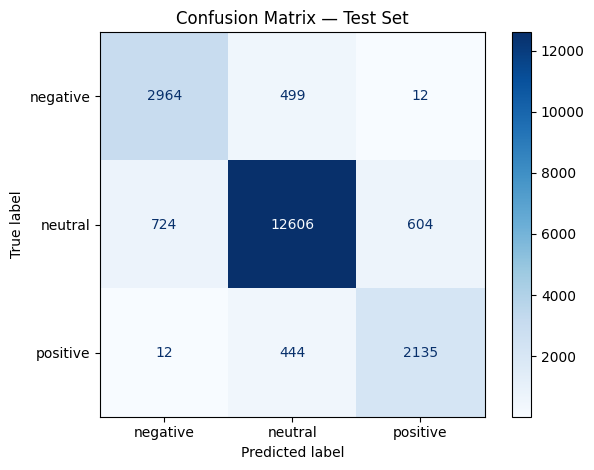

In [14]:
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=list(ID2LABEL.values()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()